In [51]:
library(tidyverse)
library(fixest)   
library(data.table)
library(broom)
library(dplyr)
library(ggplot2)
library(readr)

# Question 1 — TWFE & Event-Study

## a) TWFE

In [56]:
data <- read.csv("C:/Users/VICTOR/Documents/GitHub/CSDiD/R/Input/bacon_example.csv")
head(data)
str(data)
twfe_model <- feols(asmrs ~ post + pcinc + asmrh + cases | 
                    stfips + year, 
                    data = data)

cat("\n=== RESULTADOS TWFE ===\n")
summary(twfe_model)

,stfips,year,X_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1964,1971,0,35.63988,12406.18,5.007341,0.012312243,1715156,1715156
2,1,1965,1971,0,41.54375,13070.21,4.425367,0.010419407,1715156,1725186
3,1,1966,1971,0,34.25233,13526.66,4.874819,0.009900097,1715156,1735219
4,1,1967,1971,0,34.46502,13918.19,5.362014,0.009974692,1715156,1745250
5,1,1968,1971,0,40.44011,14684.81,4.643759,0.012400659,1715156,1755283
6,1,1969,1971,0,42.49012,15638.88,5.296976,0.015006756,1715156,1765316


'data.frame':	1617 obs. of  10 variables:
 $ stfips: int  1 1 1 1 1 1 1 1 1 1 ...
 $ year  : int  1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 ...
 $ X_nfd : int  1971 1971 1971 1971 1971 1971 1971 1971 1971 1971 ...
 $ post  : int  0 0 0 0 0 0 0 1 1 1 ...
 $ asmrs : num  35.6 41.5 34.3 34.5 40.4 ...
 $ pcinc : num  12406 13070 13527 13918 14685 ...
 $ asmrh : num  5.01 4.43 4.87 5.36 4.64 ...
 $ cases : num  0.01231 0.01042 0.0099 0.00997 0.0124 ...
 $ weight: num  1715156 1715156 1715156 1715156 1715156 ...
 $ copop : num  1715156 1725186 1735219 1745250 1755283 ...

=== RESULTADOS TWFE ===


OLS estimation, Dep. Var.: asmrs
Observations: 1,617
Fixed-effects: stfips: 49,  year: 33
Standard-errors: IID 
         Estimate Std. Error  t value   Pr(>|t|)    
post    -2.515964   1.099745 -2.28777 2.2287e-02 *  
pcinc   -0.001118   0.000206 -5.41653 7.0463e-08 ***
asmrh    1.184598   0.315274  3.75736 1.7815e-04 ***
cases -178.517916  53.939505 -3.30960 9.5601e-04 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 10.6     Adj. R2: 0.693695
             Within R2: 0.034601

## b) Cleaning


=== TABLA DE FRECUENCIAS DE EVENT_TIME ===
# A tibble: 50 × 2
   event_time     n
        <int> <int>
 1        -21     1
 2        -20     2
 3        -19     2
 4        -18     2
 5        -17     2
 6        -16     3
 7        -15     3
 8        -14     3
 9        -13     6
10        -12     7
# ℹ 40 more rows

=== RESUMEN DESCRIPTIVO ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-21.000  -2.000   6.000   6.417  15.000  27.000     264 


Warning message:
"Removed 264 rows containing non-finite outside the scale range (`stat_count()`)."



Rango de event_time: NA a NA 
Límite inferior elegido: -5 
Límite superior elegido: 5 


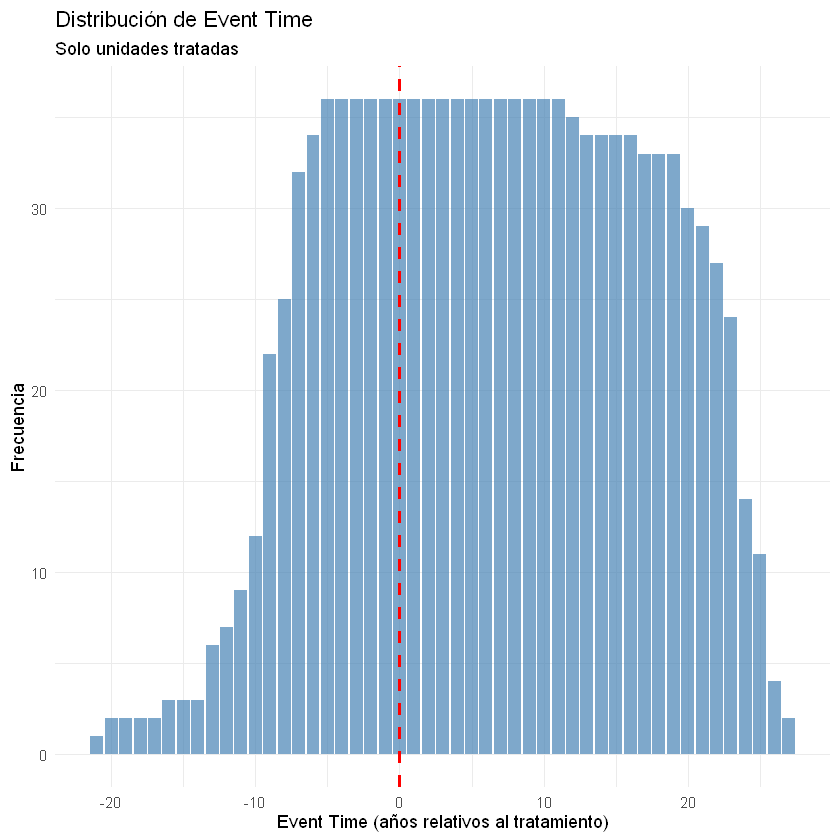

In [58]:
# 1. Crear variable de tiempo relativo (event time)
# X_nfd contiene el año de tratamiento para cada unidad
# Para unidades nunca tratadas, X_nfd podría ser un valor especial
data <- data %>%
  mutate(
    # Calcular event_time como diferencia entre año actual y año de tratamiento
    event_time = year - X_nfd,
    # Identificar unidades tratadas (aquellas donde post eventualmente es 1)
    ever_treated = ifelse(any(post == 1), 1, 0)
  ) %>%
  group_by(stfips) %>%
  mutate(ever_treated = max(post)) %>%  # 1 si alguna vez fue tratada, 0 si nunca
  ungroup()

# Para análisis Event-Study, solo usamos unidades tratadas
data_treated <- data %>% filter(ever_treated == 1)

# 2. Tabla de frecuencias del event time
freq_table <- data_treated %>%
  count(event_time) %>%
  arrange(event_time)

cat("\n=== TABLA DE FRECUENCIAS DE EVENT_TIME ===\n")
print(freq_table)

# Resumen descriptivo
cat("\n=== RESUMEN DESCRIPTIVO ===\n")
print(summary(data_treated$event_time))

# 3. Elegir límites razonables basados en la distribución
# Analizar la distribución
dist_plot <- ggplot(data_treated, aes(x = event_time)) +
  geom_bar(fill = "steelblue", alpha = 0.7) +
  labs(title = "Distribución de Event Time",
       subtitle = "Solo unidades tratadas",
       x = "Event Time (años relativos al tratamiento)",
       y = "Frecuencia") +
  theme_minimal() +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1)

print(dist_plot)

# Determinar el rango de event_time
min_et <- min(data_treated$event_time)
max_et <- max(data_treated$event_time)

cat(paste("\nRango de event_time:", min_et, "a", max_et, "\n"))

# Basado en la distribución, elegir bounds
# Ajustar según lo que veas en la distribución
lower_bound <- -5
upper_bound <- 5

cat(paste("Límite inferior elegido:", lower_bound, "\n"))
cat(paste("Límite superior elegido:", upper_bound, "\n"))

> Respuesta: Se agrupan los tiempos mas lejanos porque en los extremos suelen quedar pocas observaciones, lo cual genera ruido en las estimaciones: intervalos de confianza grandes

In [59]:
# 5. Crear variables dummy de tiempo relativo
# Agrupar los extremos
data_treated <- data_treated %>%
  mutate(event_time_binned = case_when(
    event_time < lower_bound ~ lower_bound,
    event_time > upper_bound ~ upper_bound,
    TRUE ~ event_time
  ))

# Verificar la agrupación
cat("\n=== DISTRIBUCIÓN DE EVENT_TIME_BINNED ===\n")
print(table(data_treated$event_time_binned))

# Crear dummies para cada período (excepto -1, que es la referencia)
event_times <- sort(unique(data_treated$event_time_binned))

# Crear dummies manualmente (aunque fixest lo hará automáticamente)
for(et in event_times) {
  if(et != -1) {  # -1 es el período de referencia
    var_name <- paste0("event_time_", ifelse(et < 0, "m", "p"), abs(et))
    data_treated[[var_name]] <- as.numeric(data_treated$event_time_binned == et)
  }
}

cat("\nDummies creadas para event_time (excepto -1 como referencia)\n")



=== DISTRIBUCIÓN DE EVENT_TIME_BINNED ===

 -5  -4  -3  -2  -1   0   1   2   3   4   5 
201  36  36  36  36  36  36  36  36  36 663 

Dummies creadas para event_time (excepto -1 como referencia)


## c) Event Study

NOTE: 264 observations removed because of NA values (RHS: 264).




=== RESULTADOS EVENT-STUDY ===


OLS estimation, Dep. Var.: asmrs
Observations: 1,188
Fixed-effects: stfips: 36,  year: 33
Standard-errors: IID 
                         Estimate Std. Error   t value  Pr(>|t|)    
event_time_binned::-5   -4.868901   2.432296 -2.001771 0.0455530 *  
event_time_binned::-4   -0.984711   2.753095 -0.357674 0.7206553    
event_time_binned::-3   -3.391411   2.664239 -1.272938 0.2033074    
event_time_binned::-2   -0.797059   2.660595 -0.299579 0.7645543    
event_time_binned::0     1.316511   2.661522  0.494646 0.6209481    
event_time_binned::1    -0.205565   2.661955 -0.077223 0.9384599    
event_time_binned::2     0.939158   2.755041  0.340887 0.7332532    
event_time_binned::3     2.080297   2.801503  0.742565 0.4579029    
event_time_binned::4     0.807818   2.902639  0.278305 0.7808305    
event_time_binned::5    -0.038004   2.634018 -0.014428 0.9884909    
pcinc                   -0.000723   0.000238 -3.041624 0.0024084 ** 
asmrh                    0.546594   0.368829  1.481971 0.138

[1] "Coeficientes del Event-Study:"
                      event_time coefficient       se  ci_lower   ci_upper
event_time_binned::-5         -5 -4.86890103 2.432296 -9.636202 -0.1016005
event_time_binned::-4         -4 -0.98471116 2.753095 -6.380777  4.4113552
event_time_binned::-3         -3 -3.39141109 2.664239 -8.613320  1.8304982
event_time_binned::-2         -2 -0.79705912 2.660595 -6.011825  4.4177069
1                             -1  0.00000000 0.000000  0.000000  0.0000000
event_time_binned::0           0  1.31651115 2.661522 -3.900071  6.5330933
event_time_binned::1           1 -0.20556492 2.661955 -5.422998  5.0118679
event_time_binned::2           2  0.93915812 2.755041 -4.460722  6.3390385
event_time_binned::3           3  2.08029679 2.801503 -3.410649  7.5712423
event_time_binned::4           4  0.80781793 2.902639 -4.881355  6.4969909
event_time_binned::5           5 -0.03800423 2.634018 -5.200680  5.1246717


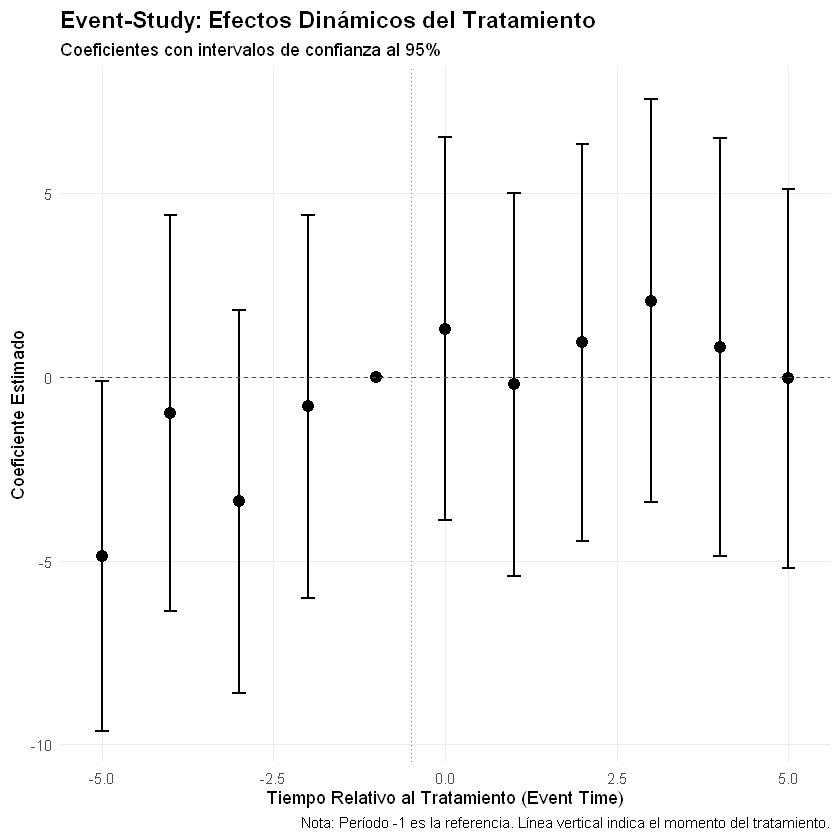

In [60]:
# 1. Estimar modelo Event-Study
# Usar i() de fixest para crear automáticamente las dummies y excluir -1 como referencia
event_study_model <- feols(asmrs ~ i(event_time_binned, ref = -1) + 
                           pcinc + asmrh + cases | 
                           stfips + year, 
                           data = data_treated)

# Mostrar resultados
cat("\n=== RESULTADOS EVENT-STUDY ===\n")
summary(event_study_model)

# 2. Almacenar coeficientes y errores estándar
# Extraer coeficientes relacionados con event_time
coef_names <- names(coef(event_study_model))
event_coefs <- coef_names[grepl("event_time_binned", coef_names)]

# Crear dataframe con resultados
results_df <- data.frame(
  event_time = as.numeric(gsub("event_time_binned::", "", event_coefs)),
  coefficient = coef(event_study_model)[event_coefs],
  se = se(event_study_model)[event_coefs]
)

# Añadir el período de referencia (-1) con coeficiente 0
results_df <- rbind(results_df, 
                    data.frame(event_time = -1, 
                              coefficient = 0, 
                              se = 0))
results_df <- results_df %>% arrange(event_time)

# Calcular intervalos de confianza (95%)
results_df <- results_df %>%
  mutate(
    ci_lower = coefficient - 1.96 * se,
    ci_upper = coefficient + 1.96 * se
  )

print("Coeficientes del Event-Study:")
print(results_df)

# 3. Graficar los coeficientes del event-study
event_study_plot <- ggplot(results_df, aes(x = event_time, y = coefficient)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
                width = 0.2, 
                linewidth = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_vline(xintercept = -0.5, linetype = "dotted", color = "gray50") +
  labs(
    title = "Event-Study: Efectos Dinámicos del Tratamiento",
    subtitle = "Coeficientes con intervalos de confianza al 95%",
    x = "Tiempo Relativo al Tratamiento (Event Time)",
    y = "Coeficiente Estimado",
    caption = "Nota: Período -1 es la referencia. Línea vertical indica el momento del tratamiento."
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank()
  )

# Mostrar gráfico
print(event_study_plot)

# Question 2 — CSDiD

# a)

# b)

# c)

# d)